<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


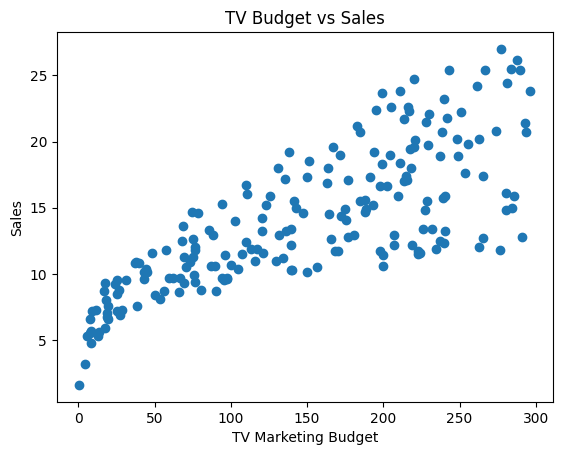

X_train shape: (160, 1)
X_test shape: (40, 1)
y_train shape: (160,)
y_test shape: (40,)
Intercept (b0): 7.119638430592953
Slope (b1): 0.046529733705443346


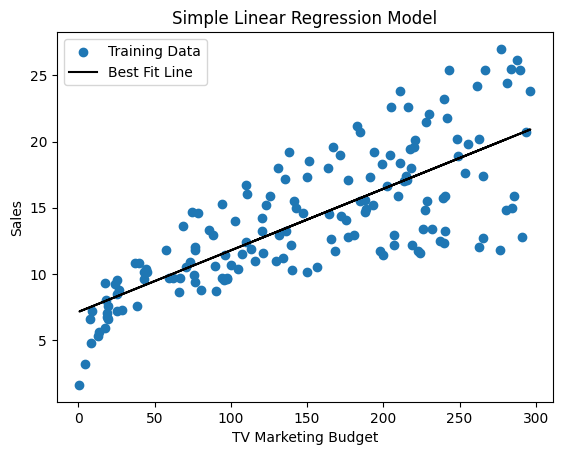

    Actual Sales  Predicted Sales
0           16.9        14.717944
1           22.4        16.211548
2           21.4        20.748197
3            7.3         7.664036
4           24.7        17.370139
5           12.6        10.614021
6           22.3        17.207285
7            8.4         9.446125
8           11.5        17.467851
9           14.9        15.266995
10           9.5         8.585325
11           8.7         9.734609
12          11.9        18.030861
13           5.3         7.370899
14          10.3        13.610536
15          11.7        15.038999
16           5.5         7.459305
17          16.6        16.313914
18          11.3        10.623327
19          18.9        18.165797
20          19.7        17.798212
21          12.5        10.274354
22          10.9         8.887768
23          22.2        18.793949
24           9.3        10.330190
25           8.1         9.608979
26          21.7        17.053737
27          13.4        13.601230
28          10

In [1]:
# (a)
import pandas as pd

# Load dataset directly from GitHub
url = "https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv"
df = pd.read_csv(url)

# Display first 5 rows
df.head()
# Dataset information
df.info()
# Statistical summary
df.describe()


# (b)
import matplotlib.pyplot as plt

plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Marketing Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

# (c)
from sklearn.model_selection import train_test_split

X = df[['TV']]      # Predictor
y = df['Sales']     # Target

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# (d)
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)
# Model parameters
b0 = model.intercept_
b1 = model.coef_[0]

print("Intercept (b0):", b0)
print("Slope (b1):", b1)
plt.scatter(X_train, y_train, label="Training Data")
plt.plot(X_train, model.predict(X_train), color='black', label="Best Fit Line")
plt.xlabel("TV Marketing Budget")
plt.ylabel("Sales")
plt.title("Simple Linear Regression Model")
plt.legend()
plt.show()
# Predict on test data


# (e)
y_pred = model.predict(X_test)

# Create comparison table
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(comparison)

# (f)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 Score
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)
